# Car Defect Detection — YOLO Segmentation Dataset Prep

**Goal:** Build a clean YOLO-seg dataset from the first 2,200 re-annotated images only.

**What this notebook does:**
1. Loads the COCO JSON exported from CVAT.
2. Inspects the **original class IDs/names**.
3. **Remaps** 10 original classes → 8 merged classes via `CLASS_MAPPING`.
4. Takes only the **first 2,200 images** (sorted by filename).
5. **Drops unlabeled images** from those 2,200 — we do NOT backfill with images > 2,200.
6. Studies the resulting clean dataset (class distribution, image sizes, etc.).
7. Splits into **train / val / test**.
8. Converts annotations to **YOLO segmentation format** (`*.txt` with polygon segments).
9. Writes the final `dataset.yaml` for YOLOv8-seg training.

> **Important:** Only the first 2,200 images are re-annotated. Images 2,201–5,435 are still unclean and must be ignored entirely.

In [8]:
import json
import os
import shutil
import random
from pathlib import Path
from collections import Counter, defaultdict
import numpy as np
from sklearn.model_selection import train_test_split

# ============================================================
# CELL 1: Configuration & Paths
# ============================================================

RAW_DATA_DIR = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/Car defect 2200"
RAW_ANNOTATIONS_PATH = os.path.join(RAW_DATA_DIR, "annotations", "instances_default.json")
RAW_IMAGES_DIR = os.path.join(RAW_DATA_DIR, "images", "default")

OUTPUT_DIR = "/Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/yolo_seg_clean_2200_"

TRUSTED_IMAGE_COUNT = 2200

TRAIN_RATIO = 0.80
VAL_RATIO   = 0.1
TEST_RATIO  = 0.1

CLASS_MAPPING = {
    1: 0,   # dent -> dent
    2: 0,   # ding -> dent
    3: 1,   # deform -> deform
    4: 2,   # scratch_hairline -> scratch
    5: 2,   # scratch_gouge -> scratch
    6: 3,   # crack -> crack
    7: 4,   # glass_shatter -> glass_shatter
    8: 5,   # broken_lamp -> broken_lamp
    9: 6,   # corrosion -> corrosion
    10: 7,  # broken_components -> disjoint_part
}

NEW_CLASS_NAMES = [
    'dent', 'deform', 'scratch', 'crack',
    'glass_shatter', 'broken_lamp', 'corrosion', 'disjoint_part'
]

random.seed(42)
np.random.seed(42)

print("Configuration loaded.")
print(f"Raw annotations : {RAW_ANNOTATIONS_PATH}")
print(f"Raw images dir  : {RAW_IMAGES_DIR}")
print(f"Output dir      : {OUTPUT_DIR}")
print(f"Class mapping   : {len(CLASS_MAPPING)} original -> {len(NEW_CLASS_NAMES)} merged classes")

Configuration loaded.
Raw annotations : /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/Car defect 2200/annotations/instances_default.json
Raw images dir  : /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/raw/Car defect 2200/images/default
Output dir      : /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/yolo_seg_clean_2200_
Class mapping   : 10 original -> 8 merged classes


In [9]:
# ============================================================
# CELL 2: Load COCO Annotations & Inspect Original Classes
# ============================================================

with open(RAW_ANNOTATIONS_PATH, 'r') as f:
    coco_data = json.load(f)

print("=== COCO Dataset Info ===")
print(f"Total images in JSON       : {len(coco_data['images'])}")
print(f"Total annotations in JSON  : {len(coco_data['annotations'])}")
print(f"Total categories in JSON   : {len(coco_data['categories'])}")

print("\n=== Original Categories (Classes) ===")
for cat in sorted(coco_data['categories'], key=lambda x: x['id']):
    new_idx = CLASS_MAPPING.get(cat['id'], '?')
    new_name = NEW_CLASS_NAMES[new_idx] if isinstance(new_idx, int) else '?'
    print(f"  ID: {cat['id']:2d} | Name: {cat['name']:25s} -> YOLO {new_idx}: {new_name}")

image_id_to_filename = {img['id']: img['file_name'] for img in coco_data['images']}
filename_to_image_id = {img['file_name']: img['id'] for img in coco_data['images']}
image_id_to_size     = {img['id']: (img['width'], img['height']) for img in coco_data['images']}

annotations_by_image = defaultdict(list)
for ann in coco_data['annotations']:
    annotations_by_image[ann['image_id']].append(ann)

print(f"\n=== Annotation Distribution ===")
print(f"Images with >=1 annotation : {len(annotations_by_image)}")
print(f"Images with ZERO annotation: {len(coco_data['images']) - len(annotations_by_image)}")

=== COCO Dataset Info ===
Total images in JSON       : 5435
Total annotations in JSON  : 37558
Total categories in JSON   : 10

=== Original Categories (Classes) ===
  ID:  1 | Name: dent                      -> YOLO 0: dent
  ID:  2 | Name: ding                      -> YOLO 0: dent
  ID:  3 | Name: deform                    -> YOLO 1: deform
  ID:  4 | Name: scratch_hairline          -> YOLO 2: scratch
  ID:  5 | Name: scratch_gouge             -> YOLO 2: scratch
  ID:  6 | Name: crack                     -> YOLO 3: crack
  ID:  7 | Name: glass_shatter             -> YOLO 4: glass_shatter
  ID:  8 | Name: broken_lamp               -> YOLO 5: broken_lamp
  ID:  9 | Name: corrosion                 -> YOLO 6: corrosion
  ID: 10 | Name: broken_components         -> YOLO 7: disjoint_part

=== Annotation Distribution ===
Images with >=1 annotation : 5062
Images with ZERO annotation: 373


In [10]:
# ============================================================
# CELL 3: Select First 2,200 Images & Drop Unlabeled Ones
# ============================================================

# Sort all image filenames alphabetically (same order as ls)
all_filenames = sorted([img['file_name'] for img in coco_data['images']])
print(f"Total filenames in JSON: {len(all_filenames)}")

# Take ONLY the first 2,200 filenames
trusted_filenames = set(all_filenames[:TRUSTED_IMAGE_COUNT])
print(f"First 2,200 filenames selected (by sorted order).")

# From those 2,200, keep only images that have at least one annotation
labeled_trusted = []
unlabeled_trusted = []

for fname in sorted(trusted_filenames):
    img_id = filename_to_image_id[fname]
    if img_id in annotations_by_image and len(annotations_by_image[img_id]) > 0:
        labeled_trusted.append(fname)
    else:
        unlabeled_trusted.append(fname)

print(f"\n=== After filtering unlabeled from first 2,200 ===")
print(f"Labeled images   : {len(labeled_trusted)}")
print(f"Unlabeled images : {len(unlabeled_trusted)}  <-- DROPPED, NOT backfilled")
print(f"Final clean set  : {len(labeled_trusted)} images")

# Show some dropped filenames for sanity check
if unlabeled_trusted:
    print(f"\nSample dropped (unlabeled) filenames:")
    for fname in unlabeled_trusted[:10]:
        print(f"  - {fname}")

Total filenames in JSON: 5435
First 2,200 filenames selected (by sorted order).

=== After filtering unlabeled from first 2,200 ===
Labeled images   : 2019
Unlabeled images : 181  <-- DROPPED, NOT backfilled
Final clean set  : 2019 images

Sample dropped (unlabeled) filenames:
  - cardd_test_000057.jpg
  - cardd_test_000353.jpg
  - cardd_test_000603.jpg
  - cardd_test_000659.jpg
  - cardd_test_000670.jpg
  - cardd_test_000720.jpg
  - cardd_test_000730.jpg
  - cardd_test_000740.jpg
  - cardd_test_000749.jpg
  - cardd_test_000778.jpg


In [11]:
# ============================================================
# CELL 4: Study the Clean Dataset Before Splitting
# ============================================================

clean_image_ids = [filename_to_image_id[f] for f in labeled_trusted]

class_counter = Counter()
original_class_names = {cat['id']: cat['name'] for cat in coco_data['categories']}

for img_id in clean_image_ids:
    for ann in annotations_by_image[img_id]:
        new_idx = CLASS_MAPPING[ann['category_id']]
        class_counter[NEW_CLASS_NAMES[new_idx]] += 1

print("=== Class Distribution After Remapping (annotation count) ===")
for cls_name, count in class_counter.most_common():
    print(f"  {cls_name:25s}: {count:5d}")

images_per_class = defaultdict(set)
for img_id in clean_image_ids:
    for ann in annotations_by_image[img_id]:
        new_idx = CLASS_MAPPING[ann['category_id']]
        images_per_class[NEW_CLASS_NAMES[new_idx]].add(img_id)

print(f"\n=== Images Containing Each Class (after remapping) ===")
for cls_name in sorted(images_per_class.keys()):
    print(f"  {cls_name:25s}: {len(images_per_class[cls_name]):5d} images")

widths, heights = [], []
for img_id in clean_image_ids:
    w, h = image_id_to_size[img_id]
    widths.append(w)
    heights.append(h)

print(f"\n=== Image Size Statistics ===")
print(f"Width  — min: {min(widths)}, max: {max(widths)}, mean: {np.mean(widths):.1f}")
print(f"Height — min: {min(heights)}, max: {max(heights)}, mean: {np.mean(heights):.1f}")

ann_counts = [len(annotations_by_image[img_id]) for img_id in clean_image_ids]
print(f"\n=== Annotations per Image ===")
print(f"Min: {min(ann_counts)}, Max: {max(ann_counts)}, Mean: {np.mean(ann_counts):.2f}")
print(f"Images with 1 annotation : {sum(1 for c in ann_counts if c == 1)}")
print(f"Images with >1 annotation: {sum(1 for c in ann_counts if c > 1)}")

=== Class Distribution After Remapping (annotation count) ===
  scratch                  :  3089
  dent                     :  1179
  crack                    :   581
  disjoint_part            :   501
  broken_lamp              :   406
  deform                   :   385
  glass_shatter            :   252
  corrosion                :   241

=== Images Containing Each Class (after remapping) ===
  broken_lamp              :   399 images
  corrosion                :    78 images
  crack                    :   369 images
  deform                   :   315 images
  dent                     :   874 images
  disjoint_part            :   376 images
  glass_shatter            :   250 images
  scratch                  :  1353 images

=== Image Size Statistics ===
Width  — min: 563, max: 1000, mean: 978.6
Height — min: 333, max: 1000, mean: 706.2

=== Annotations per Image ===
Min: 1, Max: 23, Mean: 3.29
Images with 1 annotation : 630
Images with >1 annotation: 1389


In [12]:
# ============================================================
# CELL 5: Split into Train / Val / Test
# ============================================================

def get_dominant_class(img_id):
    class_counts = Counter()
    for ann in annotations_by_image[img_id]:
        new_idx = CLASS_MAPPING[ann['category_id']]
        class_counts[NEW_CLASS_NAMES[new_idx]] += 1
    return class_counts.most_common(1)[0][0]

stratify_labels = [get_dominant_class(img_id) for img_id in clean_image_ids]

train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    clean_image_ids,
    stratify_labels,
    test_size=(VAL_RATIO + TEST_RATIO),
    random_state=42,
    stratify=stratify_labels
)

val_ratio_adjusted = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids,
    temp_labels,
    test_size=(1 - val_ratio_adjusted),
    random_state=42,
    stratify=temp_labels
)

train_files = [image_id_to_filename[i] for i in train_ids]
val_files   = [image_id_to_filename[i] for i in val_ids]
test_files  = [image_id_to_filename[i] for i in test_ids]

print(f"=== Split Results ===")
print(f"Train : {len(train_files)} images ({len(train_files)/len(clean_image_ids)*100:.1f}%)")
print(f"Val   : {len(val_files)} images ({len(val_files)/len(clean_image_ids)*100:.1f}%)")
print(f"Test  : {len(test_files)} images ({len(test_files)/len(clean_image_ids)*100:.1f}%)")
print(f"Total : {len(train_files)+len(val_files)+len(test_files)} images")

assert len(set(train_files) & set(val_files)) == 0, "Train/Val overlap!"
assert len(set(train_files) & set(test_files)) == 0, "Train/Test overlap!"
assert len(set(val_files) & set(test_files)) == 0, "Val/Test overlap!"
print("\n\u2713 No overlaps between splits.")

=== Split Results ===
Train : 1615 images (80.0%)
Val   : 202 images (10.0%)
Test  : 202 images (10.0%)
Total : 2019 images

✓ No overlaps between splits.


In [13]:
# ============================================================
# CELL 6: Convert to YOLO Segmentation Format
# ============================================================

# YOLO seg format: <class_id> <x1> <y1> <x2> <y2> ... <xn> <yn>
# All coordinates normalized to [0, 1]

yolo_idx_to_name = {i: name for i, name in enumerate(NEW_CLASS_NAMES)}

print("=== YOLO Class Mapping (via CLASS_MAPPING) ===")
sorted_cats = sorted(coco_data['categories'], key=lambda x: x['id'])
for cat in sorted_cats:
    new_idx = CLASS_MAPPING[cat['id']]
    print(f"  COCO id {cat['id']:2d} ({cat['name']:25s}) -> YOLO idx {new_idx} ({NEW_CLASS_NAMES[new_idx]})")

def polygon_to_yolo_seg(ann, img_w, img_h):
    segs = ann.get('segmentation', [])
    if not segs:
        return None

    if isinstance(segs, dict):
        return None

    if isinstance(segs[0], (int, float)):
        segs = [segs]

    yolo_lines = []
    for poly in segs:
        if len(poly) < 6:
            continue
        normalized = []
        for i in range(0, len(poly), 2):
            x = poly[i] / img_w
            y = poly[i+1] / img_h
            normalized.extend([x, y])
        if normalized:
            cls_idx = CLASS_MAPPING[ann['category_id']]
            line = f"{cls_idx} " + " ".join(f"{v:.6f}" for v in normalized)
            yolo_lines.append(line)

    return yolo_lines

def process_split(file_list, split_name):
    split_img_dir = os.path.join(OUTPUT_DIR, split_name, "images")
    split_lbl_dir = os.path.join(OUTPUT_DIR, split_name, "labels")
    os.makedirs(split_img_dir, exist_ok=True)
    os.makedirs(split_lbl_dir, exist_ok=True)

    skipped_images = 0
    total_annotations = 0

    for fname in file_list:
        img_id = filename_to_image_id[fname]
        src_path = os.path.join(RAW_IMAGES_DIR, fname)
        dst_img_path = os.path.join(split_img_dir, fname)

        if not os.path.exists(src_path):
            skipped_images += 1
            continue

        shutil.copy2(src_path, dst_img_path)

        img_w, img_h = image_id_to_size[img_id]
        anns = annotations_by_image.get(img_id, [])

        label_lines = []
        for ann in anns:
            if ann['category_id'] not in CLASS_MAPPING:
                continue
            lines = polygon_to_yolo_seg(ann, img_w, img_h)
            if lines:
                label_lines.extend(lines)

        stem = os.path.splitext(fname)[0]
        lbl_path = os.path.join(split_lbl_dir, stem + ".txt")
        with open(lbl_path, 'w') as f:
            f.write("\n".join(label_lines))
            if label_lines:
                f.write("\n")

        total_annotations += len(label_lines)

    print(f"[{split_name:5s}] Images: {len(file_list)-skipped_images}, skipped: {skipped_images}, label lines: {total_annotations}")
    return len(file_list) - skipped_images

print("\n=== Converting to YOLO Seg Format ===")
train_n = process_split(train_files, "train")
val_n   = process_split(val_files,   "val")
test_n  = process_split(test_files,  "test")
print(f"\nDone. Total images written: {train_n + val_n + test_n}")

=== YOLO Class Mapping (via CLASS_MAPPING) ===
  COCO id  1 (dent                     ) -> YOLO idx 0 (dent)
  COCO id  2 (ding                     ) -> YOLO idx 0 (dent)
  COCO id  3 (deform                   ) -> YOLO idx 1 (deform)
  COCO id  4 (scratch_hairline         ) -> YOLO idx 2 (scratch)
  COCO id  5 (scratch_gouge            ) -> YOLO idx 2 (scratch)
  COCO id  6 (crack                    ) -> YOLO idx 3 (crack)
  COCO id  7 (glass_shatter            ) -> YOLO idx 4 (glass_shatter)
  COCO id  8 (broken_lamp              ) -> YOLO idx 5 (broken_lamp)
  COCO id  9 (corrosion                ) -> YOLO idx 6 (corrosion)
  COCO id 10 (broken_components        ) -> YOLO idx 7 (disjoint_part)

=== Converting to YOLO Seg Format ===
[train] Images: 1615, skipped: 0, label lines: 5213
[val  ] Images: 202, skipped: 0, label lines: 693
[test ] Images: 202, skipped: 0, label lines: 727

Done. Total images written: 2019


In [14]:
# ============================================================
# CELL 7: Write dataset.yaml for YOLOv8-seg
# ============================================================

yaml_path = os.path.join(OUTPUT_DIR, "dataset.yaml")

yaml_content = f"""# YOLOv8 Segmentation Dataset
# Auto-generated for car defect detection
# Source: first 2,200 re-annotated images from CVAT export
# Classes remapped: 10 original -> {len(NEW_CLASS_NAMES)} merged via CLASS_MAPPING

path: {OUTPUT_DIR}
train: train/images
val: val/images
test: test/images

nc: {len(NEW_CLASS_NAMES)}

names:
"""

for idx, name in enumerate(NEW_CLASS_NAMES):
    yaml_content += f"  {idx}: {name}\n"

with open(yaml_path, 'w') as f:
    f.write(yaml_content)

print(f"dataset.yaml written to: {yaml_path}")
print("\n" + "="*50)
print(yaml_content)
print("="*50)

dataset.yaml written to: /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/yolo_seg_clean_2200_/dataset.yaml

# YOLOv8 Segmentation Dataset
# Auto-generated for car defect detection
# Source: first 2,200 re-annotated images from CVAT export
# Classes remapped: 10 original -> 8 merged via CLASS_MAPPING

path: /Users/macbook/Documents/ITC8/Internship/AI Farm/Project/car_defect_detection/data/processed/yolo_seg_clean_2200_
train: train/images
val: val/images
test: test/images

nc: 8

names:
  0: dent
  1: deform
  2: scratch
  3: crack
  4: glass_shatter
  5: broken_lamp
  6: corrosion
  7: disjoint_part



In [15]:
# ============================================================
# CELL 8: Verification — Spot-check a few labels
# ============================================================

import glob

print("=== Spot-check label files ===")
for split in ["train", "val", "test"]:
    lbl_dir = os.path.join(OUTPUT_DIR, split, "labels")
    lbl_files = sorted(glob.glob(os.path.join(lbl_dir, "*.txt")))
    if lbl_files:
        sample = lbl_files[0]
        with open(sample, 'r') as f:
            content = f.read().strip()
        print(f"\n[{split}] Sample: {os.path.basename(sample)}")
        print(content[:300] + ("..." if len(content) > 300 else ""))

print("\n=== File counts per split ===")
for split in ["train", "val", "test"]:
    img_dir = os.path.join(OUTPUT_DIR, split, "images")
    lbl_dir = os.path.join(OUTPUT_DIR, split, "labels")
    n_img = len(glob.glob(os.path.join(img_dir, "*.jpg")))
    n_lbl = len(glob.glob(os.path.join(lbl_dir, "*.txt")))
    print(f"  {split:5s}: {n_img} images, {n_lbl} labels")

print("\n✓ Dataset ready for YOLOv8-seg training!")
print(f"  Train command example:")
print(f"  yolo segment train data={yaml_path} model=yolov8m-seg.pt epochs=100 imgsz=640")

=== Spot-check label files ===

[train] Sample: cardd_test_000012.txt
3 0.899000 0.149925 0.898000 0.155922 0.903200 0.174663 0.897300 0.174963 0.900700 0.182609 0.904400 0.183808 0.907700 0.205397 0.911500 0.206297 0.914900 0.194903 0.908900 0.168066
6 0.124000 0.220390 0.125000 0.238381 0.128000 0.241379 0.143000 0.238381 0.171000 0.239880 0.173000 0.238381 0.175000...

[val] Sample: cardd_test_000214.txt
4 0.000000 0.734948 0.000060 0.734978 0.017530 0.743313 0.614950 1.000000 1.000000 1.000000 1.000000 0.690405 0.995490 0.686147 0.979600 0.671844 0.967690 0.663508 0.951000 0.645637 0.939880 0.626582 0.915250 0.578951 0.901750 0.553928 0.848520 0.465787 0.831840 0.440780 0.821510 0.422909 0.808000 0...

[test] Sample: cardd_test_000015.txt
2 0.336280 0.754168 0.349040 0.748186 0.363400 0.744603 0.376170 0.744603 0.388940 0.744603 0.404890 0.750585 0.418460 0.755367 0.432020 0.757766 0.446380 0.762549 0.460740 0.770915 0.473510 0.778096 0.485480 0.784078 0.498240 0.791259 0.513400 0.

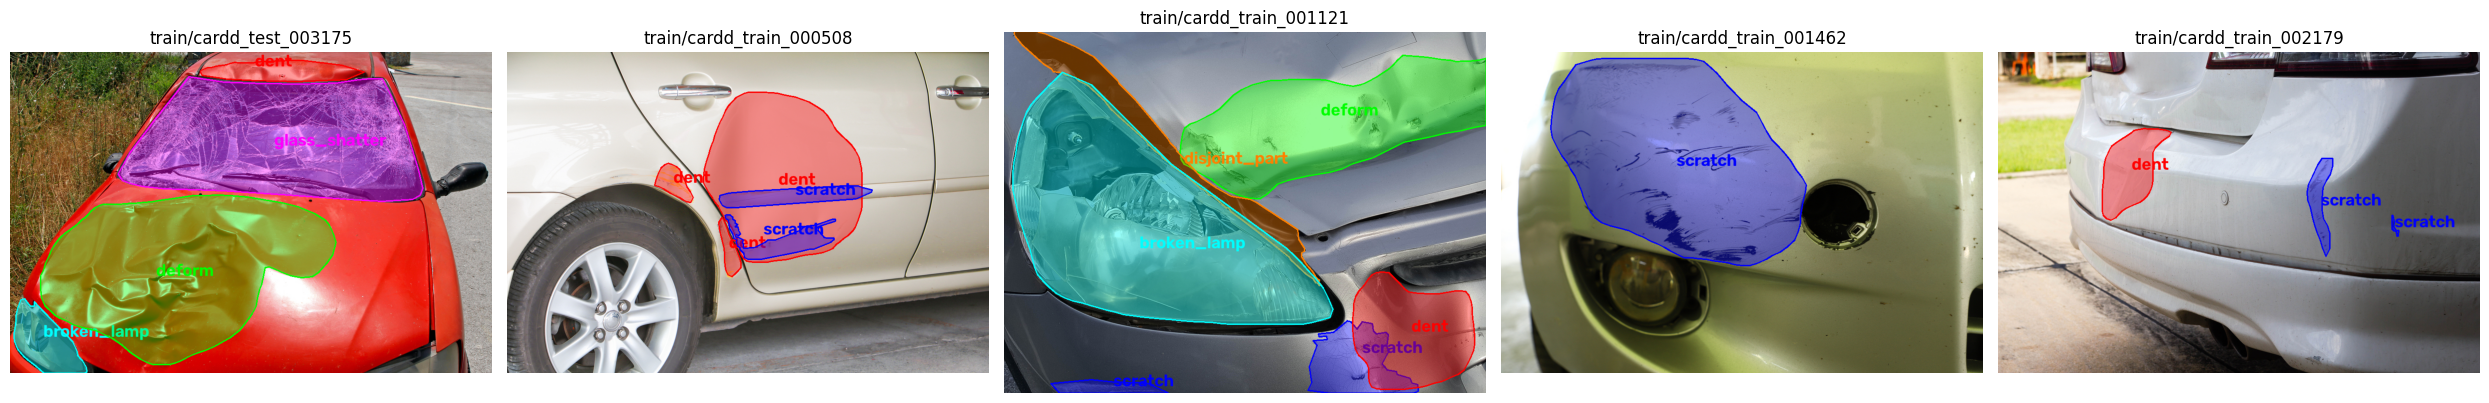

In [39]:
# ============================================================
# CELL 9: Visualize 5 Random Images with YOLO Seg Overlays
# ============================================================

import glob
import cv2
import matplotlib.pyplot as plt

COLORS = [
    (255, 0, 0), (0, 255, 0), (0, 0, 255), (255, 255, 0),
    (255, 0, 255), (0, 255, 255), (128, 0, 255), (255, 128, 0)
]

all_img_paths = []
for split in ['train', 'val', 'test']:
    all_img_paths.extend(glob.glob(os.path.join(OUTPUT_DIR, split, 'images', '*.jpg')))

samples = random.sample(all_img_paths, min(5, len(all_img_paths)))

fig, axes = plt.subplots(1, len(samples), figsize=(5 * len(samples), 5))
if len(samples) == 1:
    axes = [axes]

for ax, img_path in zip(axes, samples):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = img.shape[:2]

    stem = os.path.splitext(os.path.basename(img_path))[0]
    split_name = img_path.split(os.sep)[-3]
    lbl_path = os.path.join(OUTPUT_DIR, split_name, 'labels', stem + '.txt')

    if os.path.exists(lbl_path):
        with open(lbl_path) as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) < 7:
                    continue
                cls_idx = int(parts[0])
                coords = [float(v) for v in parts[1:]]
                pts = []
                for i in range(0, len(coords), 2):
                    pts.append([int(coords[i] * w), int(coords[i+1] * h)])
                pts = np.array(pts, dtype=np.int32)
                color = COLORS[cls_idx % len(COLORS)]
                overlay = img.copy()
                cv2.fillPoly(overlay, [pts], color)
                cv2.addWeighted(overlay, 0.4, img, 0.6, 0, img)
                cv2.polylines(img, [pts], isClosed=True, color=color, thickness=2)
                cx, cy = pts.mean(axis=0).astype(int)
                cv2.putText(img, NEW_CLASS_NAMES[cls_idx], (cx, cy),
                            cv2.FONT_HERSHEY_SIMPLEX, 1.2, color, 3)

    ax.imshow(img)
    ax.set_title(f"{split_name}/{stem}")
    ax.axis('off')

plt.tight_layout()
plt.show()